# General notebook preparation: Libaries and Datasets

At the beginning, the basic libaries that we work with need to be imported. That includes pandas for data read out, matplot libary for basic plotting, numpy for numeric operations, seaborn for advanced plotting and scipy stats for statistical calculations.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
from pathlib import Path

Here, our cleaned-up and filtered ATAC-seq dataset is imported.

In [28]:
ATAC_path_pfiltered = Path('data') / 'ATAC_pfiltered.csv'
ATAC_pfiltered = pd.read_csv(ATAC_path_pfiltered)
ATAC_seq = ATAC_pfiltered.copy()


This dataset is a subunit of ATAC_pfiltered, but only with the Tgd-cells cells.

In [29]:
ATAC_path_Tgd = Path('data') / 'ATAC_seq_gd_anot.csv'
ATAC_Tgd = pd.read_csv(ATAC_path_Tgd)
ATAC_seq_gd = ATAC_Tgd.copy()

Finally, the cleaned-up RNA-seq dataset is read out. For further analysis, a RNA-seq dataset including only the Tgd-cells is also created.

In [30]:
RNA_seq = pd.read_csv('data/mmc2.csv')
RNA_seq = RNA_seq.set_index("Unnamed: 0")  # Gennamen als Index setzen

Tgd_cells = [
    "MPP4.135+.BM",
    "preT.DN1.Th",
    "preT.DN2a.Th",
    "preT.DN2b.Th",
    "preT.DN3.Th",
    "T.DN4.Th",
    "Tgd.g1.1+d1.24a+.Th",
    "Tgd.g2+d1.24a+.Th",
    "Tgd.g2+d17.24a+.Th",
    "Tgd.Sp",
    "Tgd.g1.1+d1.LN",
    "Tgd.g2+d1.LN",
    "Tgd.g2+d17.LN"
]

RNA_Tgd = RNA_seq[Tgd_cells].copy()
RNA_Tgd.head()


,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
Unnamed: 0,,,,,,,,,,,,,
0610005C13Rik,1.021812,1.022363,1.389747,1.024819,1.024482,1.026430,1.023995,1.167561,1.024819,1.023995,1.025543,1.024819,1.023995
0610007P14Rik,204.298358,162.641117,206.945221,209.187788,198.421365,215.056475,150.742022,174.031477,115.930664,136.200789,108.850425,102.701399,137.925015
0610009B22Rik,76.418169,68.070719,82.468806,89.769337,57.661619,76.399214,47.775227,44.980534,53.461136,42.439750,28.755395,21.517647,29.122837
0610009L18Rik,16.947354,15.450717,13.573968,14.427620,8.249482,1.683173,8.554990,8.781962,29.156630,8.937625,10.815319,10.202163,9.033355
0610009O20Rik,186.261464,160.246297,125.475307,155.928005,120.692893,118.433597,94.062684,113.600798,102.445617,79.315094,84.643541,106.186930,86.383381


In [22]:
meta_cols = ["TSS", "genes.within.100Kb", "_-log10_bestPvalue", "Included.in.systematic.analysis",
             "ImmGenATAC1219.peakID", "chrom", "Summit", "mm10.60way.phastCons_scores"]
signal_cols_all = [col for col in ATAC_pfiltered.columns 
                   if col not in meta_cols 
                   and col in RNA_seq.columns] #alle Zelltypen Spaltennamen in ATAC, 
#ohne meta_cols und nur, wenn in ATAC, aber als liste und
signal_cols_all

signal_cols_tgd = Tgd_cells 

# CRE Classification
<h3> Can CREs be grouped into distinct classes based on signal level and cross-cell variability? Within all cell types or lineage specific? </h3>

## CRE Classification based on signal level and cross-cell variability on lineage-specific γδ T cells

### Preparing Dataset

Removing annotation columns except ImmGenATAC1219.peakID

In [31]:
annotation_cols = [
    "Summit",
    "chrom",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]

ATAC_signal_Tgd = ATAC_seq_gd.drop(columns=annotation_cols)
ATAC_signal_Tgd.shape

(362330, 14)

One Dataset without any annotation columns

In [ ]:
ATAC_signal_Tgd_numeric = ATAC_seq_gd[signal_cols_tgd].copy()
ATAC_signal_Tgd_numeric.shape


(362330, 13)

### Clustering of Peaks (CREs) based on lineage-specific γδ T-cells

Calculating mean signal and variance across γδ T cells for every peak 

In [13]:
peak_mean_Tgd = ATAC_signal_Tgd_numeric.mean(axis=1) # Mittelwert über alle Tgd-Zelltypen für jeden peak

peak_var_Tgd = ATAC_signal_Tgd_numeric.var(axis=1) # Varianz über alle Tgd-Zelltypen für jeden peak

#varianz und std sind redundant --> weiter mit Varianz
cre_parameter = pd.DataFrame(
    {"mean_signal": peak_mean_Tgd, "var": peak_var_Tgd})

cre_parameter.index = ATAC_signal_Tgd["ImmGenATAC1219.peakID"]
cre_parameter.head()

,mean_signal,var
ImmGenATAC1219.peakID,,
ImmGenATAC1219.peak_3,0.445385,0.174927
ImmGenATAC1219.peak_4,0.323846,0.049659
ImmGenATAC1219.peak_5,1.043846,0.676209
ImmGenATAC1219.peak_6,0.759231,0.298691
ImmGenATAC1219.peak_7,0.846923,0.516406


<h3> K-means clustering </h3>
K-means clustering is applied to mean signal and variance to group CREs by average accessibility and across-cell variability. Due to the large dataset size, a sample size of 10000 is used for silhouette score evaluation.

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

#Spaltenweise z-transformation
X_z = StandardScaler().fit_transform(cre_parameter)

silhouette_scores = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42,  n_init=20)
    labels = kmeans.fit_predict(X_z)
    score = silhouette_score(X_z, labels, sample_size=10000, random_state=42)    
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)] #index mit größten Wert zurück
print(f"\nBest number of clusters according to silhouette score: k={best_k}")

k=2: silhouette score = 0.8932
k=3: silhouette score = 0.8527
k=4: silhouette score = 0.8290
k=5: silhouette score = 0.8192
k=6: silhouette score = 0.7548
k=7: silhouette score = 0.7635
k=8: silhouette score = 0.7071
k=9: silhouette score = 0.7152

Best number of clusters according to silhouette score: k=2


Silhouette score plot for K-means clustering.

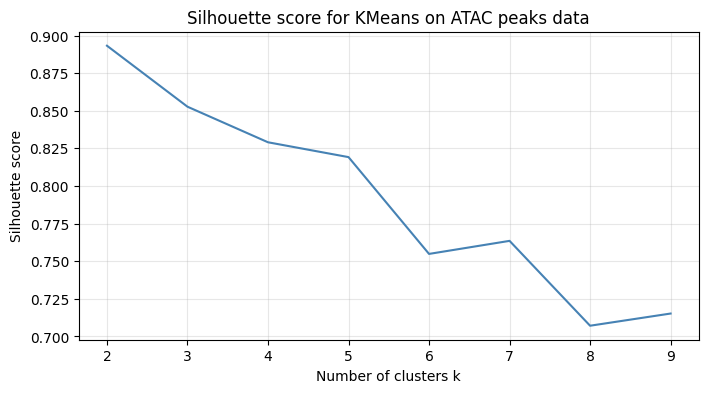

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for KMeans on ATAC peaks data")
plt.grid(True, alpha=0.3)
plt.show()

Although the highest score is achieved  by k=2, k=4 is selected for better biological interpretability.

### Selecting k=4 and visualizing cluster profiles 

In [35]:
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels = kmeans.fit_predict(X_z)
cre_parameter['cluster'] = labels

Scatter Plot of CRE Classification across lineage-specific γδ T-cells

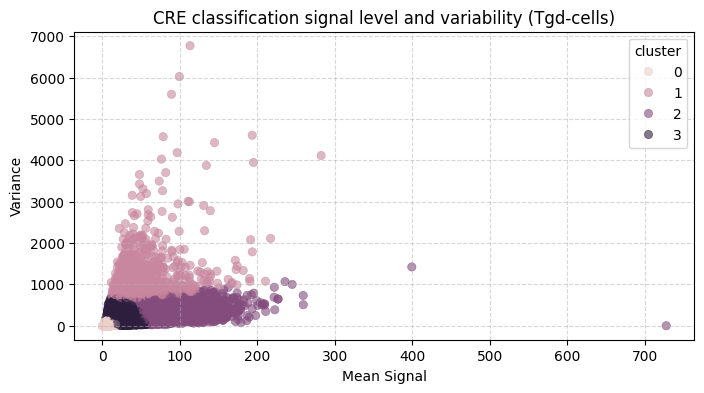

In [36]:
plt.figure(figsize=(8, 4))

sns.scatterplot(
    data=cre_parameter, 
    x="mean_signal", 
    y="var", 
    hue="cluster", 
    palette= sns.cubehelix_palette(as_cmap=True),  
    alpha=0.6,
    edgecolor=None
)

plt.xlabel("Mean Signal")
plt.ylabel("Variance")
plt.title("CRE classification signal level and variability (Tgd-cells)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Calculating the average mean signal and variance for each cluster.

In [37]:
cre_parameter.groupby('cluster')[['mean_signal','var']].mean()

,mean_signal,var
cluster,,
0,2.950395,6.600423
1,47.784021,1095.376006
2,78.615706,284.747612
3,24.103514,144.105627


Variance of mean signal and variance within each cluster.

In [38]:
cre_parameter.groupby('cluster')[['mean_signal','var']].var()

,mean_signal,var
cluster,,
0,8.637740,179.476113
1,1011.435692,357918.264566
2,955.319982,26312.614766
3,107.190215,12104.448146


Summary statistics for mean signal and variance within each cluster.

In [39]:
cre_parameter.groupby('cluster')[['mean_signal', 'var']].describe()

mean_signal                                                         \
              count       mean        std        min        25%        50%   
cluster                                                                      
0          335344.0   2.950395   2.939003   0.122308   1.050000   1.801538   
1            1065.0  47.784021  31.803077  11.444615  27.388462  38.027692   
2            3593.0  78.615706  30.908251  36.566923  58.936923  69.630769   
3           22328.0  24.103514  10.353271   4.530000  16.725192  21.755000   

                                     var                                       \
               75%         max     count         mean         std         min   
cluster                                                                         
0         3.663077   19.559231  335344.0     6.600423   13.396870    0.001036   
1        56.181538  282.133077    1065.0  1095.376006  598.262705  630.890064   
2        89.642308  727.420000    3593.0   284.747612  162.211636    0.000000   
3        30.036154   58.420769   22328.0   144.105627  110.020217    6.941797   

                                                           
                25%         50%          75%          max  
cluster                                                    
0          0.619523    1.622886     5.682626   163.624803  
1        757.282823  905.862876  1184.707124  6769.374424  
2        161.349926  247.787659   380.301927  1421.003610  
3         67.165475  110.955406   183.069428   648.230000

<p> A cluster number of k=4 was chosen. By testing k=2 to 5, it was shown that 4 is the most logical choice. </p> 
Cluster 0 (335,344 values): Very low mean and variance (mostly closed CREs).<br>Cluster 3 (22,328 values): Low mean and low-to-medium variance (weakly active CREs).<br>Cluster 2 (3,593 values): High mean and high variance (strongly active CREs).<br>Cluster 1 (1,065 values): Very high mean and variance (very strongly active CREs).<br>
<br>Notably, almost all CREs are grouped into Cluster 0, by which it is indicated that most are kept inactive or closed across the differentiation of the γδ T-cell lineage.

<h3>Boxplot of mean ATACseq signal per cluster</h3>

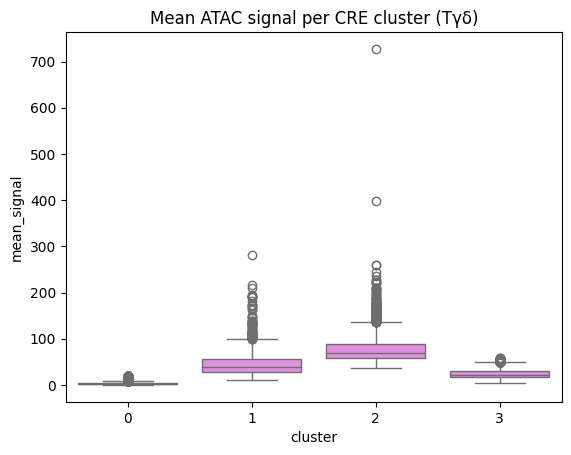

In [40]:
sns.boxplot(data=cre_parameter, x='cluster', y='mean_signal', color='violet')
plt.title('Mean ATAC signal per CRE cluster (Tγδ)')
plt.show()

<h3>Boxplot of ATACseq signal variance per cluster</h3>

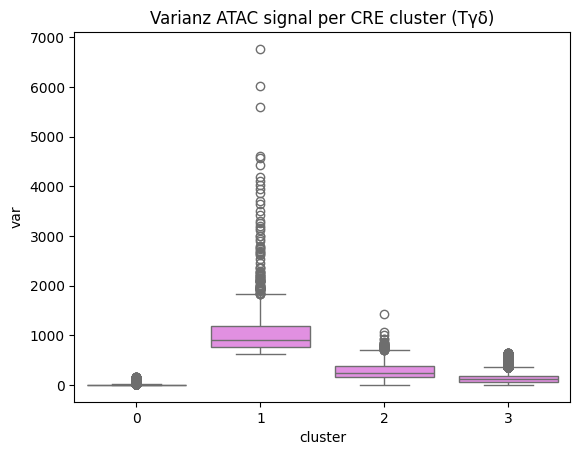

In [41]:
sns.boxplot(data=cre_parameter, x='cluster', y='var', color='violet')
plt.title('Varianz ATAC signal per CRE cluster (Tγδ)')
plt.show()

A clear separation of the clusters is confirmed by the boxplot based on their average accessibility. Inactive or closed regions are represented by Cluster 0, while a slight increase is shown by Cluster 3. Moderately active regions are captured by Cluster 1 and the most intensely open chromatin regions with the highest average signal are clearly contained within Cluster 2.

Heatmap of average accessibility per γδ T-cell sample for each cluster

Adding Cluster Labels to ATACseq Data

In [42]:
ATAC_signal_Tgd_numeric = ATAC_signal_Tgd.set_index('ImmGenATAC1219.peakID') #ImmGenATAC1219.peakID als index so das cluster_parameter und ATAC daten gleichen index haben
ATAC_signal_Tgd_numeric_cluster = ATAC_signal_Tgd_numeric.copy()
ATAC_signal_Tgd_numeric_cluster['cluster'] = cre_parameter['cluster'] #neue splate ATAC daten mit clustern von Cre parameter übernommen

ATAC_signal_Tgd_numeric_cluster.head()

,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN,cluster
ImmGenATAC1219.peakID,,,,,,,,,,,,,,
ImmGenATAC1219.peak_3,0.11,0.40,0.77,0.11,0.10,0.35,0.11,0.76,0.53,1.46,0.11,0.12,0.86,0
ImmGenATAC1219.peak_4,0.11,0.46,0.11,0.47,0.10,0.58,0.11,0.29,0.53,0.51,0.11,0.70,0.13,0
ImmGenATAC1219.peak_5,0.11,0.77,0.84,1.34,1.69,0.34,1.39,1.58,3.16,0.51,0.99,0.12,0.73,0
ImmGenATAC1219.peak_6,1.58,0.77,0.77,0.47,1.02,0.10,1.33,0.10,1.48,0.15,0.11,1.26,0.73,0
ImmGenATAC1219.peak_7,0.11,0.40,0.84,0.47,0.10,0.58,1.33,1.27,1.11,0.51,2.86,0.70,0.73,0


Grouping ATACseq data by Cluster Assignments

In [43]:
cluster_sample_mean = (
    ATAC_signal_Tgd_numeric_cluster
    .groupby('cluster')
    .mean()
)
cluster_sample_mean.head()

,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
cluster,,,,,,,,,,,,,
0,3.203880,3.077105,3.022833,2.963649,2.970361,2.982815,2.960293,2.890313,2.908988,2.913996,2.840997,2.827425,2.792482
1,57.904638,60.100347,60.771465,52.966338,44.931221,35.725681,45.908441,45.390930,46.418535,39.474357,42.281202,44.131221,45.187897
2,72.950596,76.515825,77.327370,78.618505,79.006735,79.869438,79.097286,80.630810,80.649004,81.190409,80.863270,79.908839,75.376084
3,23.339158,24.336383,24.634558,24.829462,24.322645,24.094394,24.344642,24.220262,24.461671,24.507286,24.053106,24.164920,22.037195


Heatmap: Mean accessibility per lineage-specific cell sample for each cluster

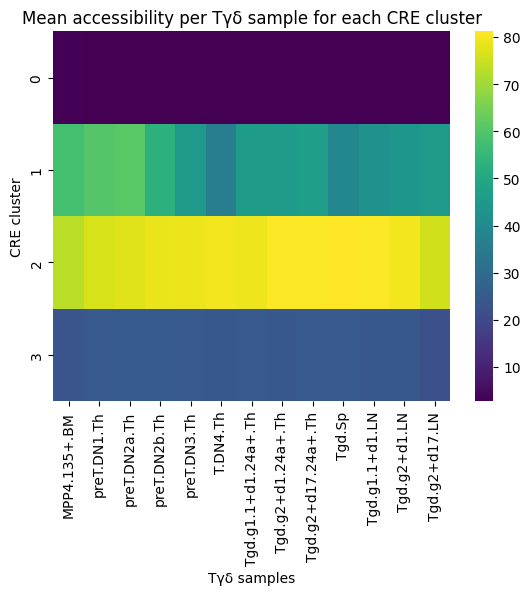

In [44]:
sns.heatmap(
    cluster_sample_mean, #Zeilen --> x-Achse, Spalten --> y-Achse, cluster spalte index nicht mitgenommen
    cmap="viridis"
)

plt.title('Mean accessibility per Tγδ sample for each CRE cluster')
plt.xlabel('Tγδ samples')
plt.ylabel('CRE cluster')
plt.show()

While it was shown by the scatter plots that Cluster 1 varies, a possible biological pattern behind this variance is revealed by the heatmap. 
It is indicated by the sharp drop in accessibility at the strongly active and high-variance cluster specifically at the T.DN4.Th stage indicates that specific genomic regions could be temporarily repressed by these elements during thymic development before they are reactivated in mature peripheral Tγδ cells.

## CRE Classification based on signal level and cross-cell variability within all cell types

### Preparing Dataset 

Removing annotation columns except ImmGenATAC1219.peakID

In [47]:
annotation_cols = [
    "Summit",
    "chrom",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]

ATAC_signal_all = ATAC_seq.drop(columns=annotation_cols)
ATAC_signal_all

,ImmGenATAC1219.peakID,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,preB.FrD.BM,B.FrE.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_3,2.36,0.10,0.90,0.11,0.47,0.10,0.50,1.17,0.32,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
1,ImmGenATAC1219.peak_4,0.41,0.10,0.11,0.11,0.79,0.40,0.50,2.23,0.80,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
2,ImmGenATAC1219.peak_5,0.41,0.10,0.11,0.11,0.47,0.34,1.78,1.17,0.32,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
3,ImmGenATAC1219.peak_6,2.36,1.64,1.85,1.58,1.12,0.34,0.42,0.13,0.80,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
4,ImmGenATAC1219.peak_7,0.41,0.10,0.11,0.11,0.11,1.34,0.90,1.69,0.80,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362325,ImmGenATAC1219.peak_512589,0.41,7.41,1.85,3.49,5.76,4.24,7.22,7.60,9.80,...,4.98,4.47,2.83,4.93,4.92,5.13,9.13,2.21,6.53,6.11
362326,ImmGenATAC1219.peak_512590,2.36,8.79,0.90,2.15,3.25,2.70,7.86,9.21,11.25,...,4.03,4.07,5.87,5.36,3.99,7.12,3.57,2.64,5.59,3.64
362327,ImmGenATAC1219.peak_512591,4.37,8.79,3.52,2.58,4.21,4.83,5.61,10.25,13.60,...,3.81,3.34,4.27,6.73,5.53,7.21,5.96,5.17,6.53,6.11
362328,ImmGenATAC1219.peak_512592,0.41,7.41,3.52,3.04,6.46,8.29,12.04,5.29,9.11,...,4.28,5.55,4.15,6.88,7.16,6.21,8.75,6.83,8.14,4.64


One Dataset without any annotation columns

In [48]:
ATAC_signal_all_numeric = ATAC_seq[signal_cols_all].copy()
ATAC_signal_all_numeric.shape

(362330, 85)

### Clustering of Peaks (CREs) based on all celltypes

Calculating mean signal and variance across all cell types for every peak 

In [49]:
peak_mean_all = ATAC_signal_all_numeric.mean(axis=1) # Mittelwert über alle Tgd-Zelltypen für jeden peak

peak_var_all = ATAC_signal_all_numeric.var(axis=1) # Varianz über alle Tgd-Zelltypen für jeden peak

#varianz und std sind redundant
cre_parameter_all = pd.DataFrame(
    {"mean_signal": peak_mean_all, "var": peak_var_all})

cre_parameter_all.index = ATAC_signal_all["ImmGenATAC1219.peakID"]
cre_parameter_all

,mean_signal,var
ImmGenATAC1219.peakID,,
ImmGenATAC1219.peak_3,1.566353,47.741669
ImmGenATAC1219.peak_4,0.864706,2.445680
ImmGenATAC1219.peak_5,0.849529,0.670419
ImmGenATAC1219.peak_6,1.104000,1.503022
ImmGenATAC1219.peak_7,0.926000,1.643422
...,...,...
ImmGenATAC1219.peak_512589,5.864235,13.976125
ImmGenATAC1219.peak_512590,5.592941,16.832290
ImmGenATAC1219.peak_512591,7.020235,24.580398


<h3> K-means clustering </h3>
K-means clustering is applied to mean signal and variance to group CREs by average accessibility and cross-cell variability. Due to the large dataset size, a sample size of 10000 is used for silhouette score evaluation.

In [53]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

#Spaltenweise z-trasnformation
X_z_all = StandardScaler().fit_transform(cre_parameter_all)

silhouette_scores = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_z_all)
    score = silhouette_score(X_z_all, labels, sample_size=10000, random_state=42)    
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]
print(f"\nBeste Clusteranzahl laut Silhouette-Score: k={best_k}")

k=2: silhouette score = 0.8879
k=3: silhouette score = 0.8292
k=4: silhouette score = 0.8159
k=5: silhouette score = 0.7878
k=6: silhouette score = 0.7824
k=7: silhouette score = 0.7502
k=8: silhouette score = 0.7207
k=9: silhouette score = 0.6989

Beste Clusteranzahl laut Silhouette-Score: k=2


Silhouette score plot for K-means clustering.

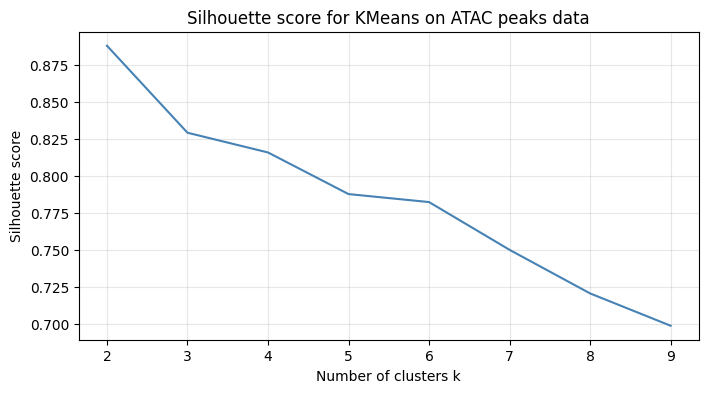

In [54]:
plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for KMeans on ATAC peaks data")
plt.grid(True, alpha=0.3)
plt.show()

Although the highest score is achieved by k=2, k=4 is selected for better biological interpretability and to allow for a direct comparison with the CRE classification for γδ T-cell development.

### Selecting k=4 and visualizing cluster profiles 

In [55]:
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels = kmeans.fit_predict(X_z_all)
cre_parameter_all['cluster'] = labels

Scatter plot of CRE classification across all samples

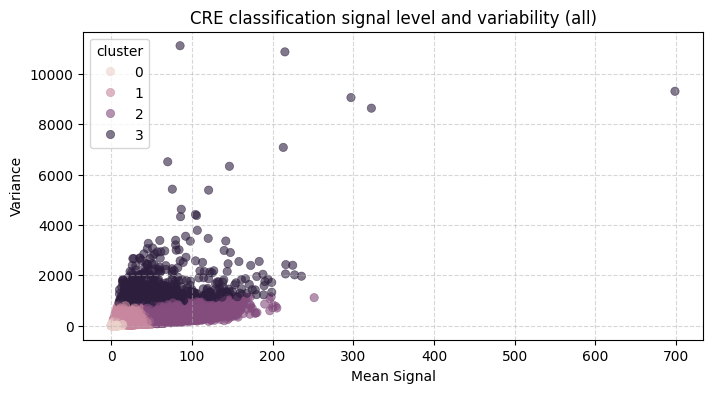

In [56]:
plt.figure(figsize=(8, 4))

sns.scatterplot(
    data=cre_parameter_all, 
    x="mean_signal", 
    y="var", 
    hue="cluster", 
    palette= sns.cubehelix_palette(as_cmap=True),    
    alpha=0.6,
    edgecolor=None
)

plt.xlabel("Mean Signal")
plt.ylabel("Variance")
plt.title("CRE classification signal level and variability (all)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Calculating the average mean signal and variance for each cluster.

In [57]:
cre_parameter_all.groupby('cluster')[['mean_signal','var']].mean()

,mean_signal,var
cluster,,
0,3.096895,14.680932
1,20.150684,209.568825
2,71.823489,391.224889
3,53.004082,1357.175913


Variance of mean signal and variance within each cluster.

In [58]:
cre_parameter_all.groupby('cluster')[['mean_signal','var']].var()

,mean_signal,var
cluster,,
0,6.670839,526.295391
1,95.459816,21277.808267
2,643.316819,39523.039121
3,2063.784004,733891.940785


Summary statistics for mean signal and variance within each cluster.

In [59]:
cre_parameter_all.groupby('cluster')[['mean_signal', 'var']].describe()

mean_signal                                                         \
              count       mean        std        min        25%        50%   
cluster                                                                      
0          333529.0   3.096895   2.582797   0.274000   1.481765   2.140824   
1           23962.0  20.150684   9.770354   2.637412  12.577971  18.233294   
2            3821.0  71.823489  25.363691  33.361529  53.960824  64.082824   
3            1018.0  53.004082  45.428890   9.793765  26.792735  37.258176   

                                     var                                       \
               75%         max     count         mean         std         min   
cluster                                                                         
0         3.667412   18.947412  333529.0    14.680932   22.941129    0.242937   
1        25.741029   51.932824   23962.0   209.568825  145.869148   17.723357   
2        82.885529  251.514118    3821.0   391.224889  198.804022   75.212258   
3        62.448324  698.482000    1018.0  1357.175913  856.674933  809.609487   

                                                             
                25%          50%          75%           max  
cluster                                                      
0          2.519188     5.569575    15.587677    206.653627  
1        106.614426   172.238293   263.406418    877.762744  
2        238.501603   342.472911   512.195359   1151.513566  
3        967.301796  1133.628537  1439.526025  11123.747823

<h3>Boxplot of mean ATACseq signal per cluster</h3>

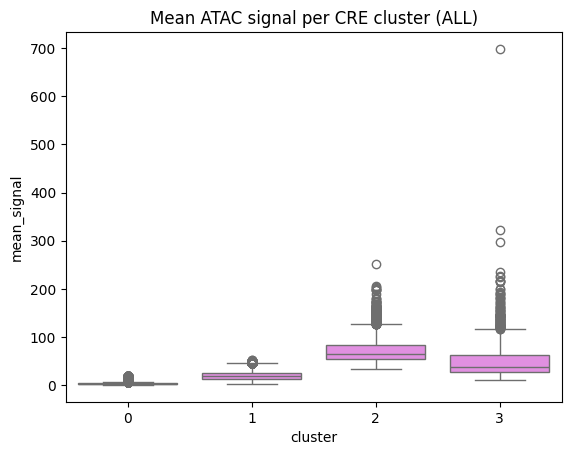

In [60]:
sns.boxplot(data=cre_parameter_all, x='cluster', y='mean_signal', color='violet')
plt.title('Mean ATAC signal per CRE cluster (ALL)')
plt.show()

<h3>Boxplot of ATACseq signal variance per cluster</h3>

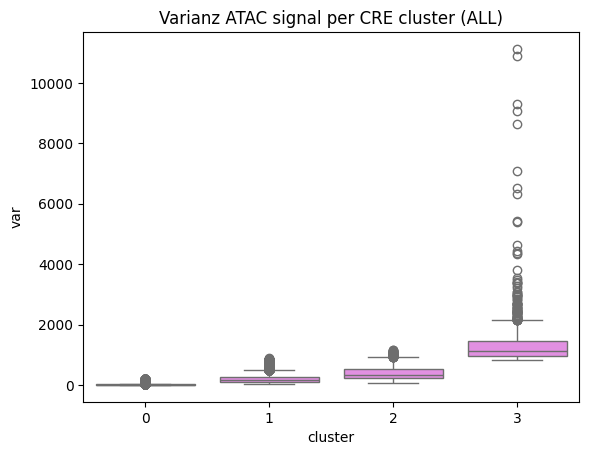

In [61]:
sns.boxplot(data=cre_parameter_all, x='cluster', y='var', color='violet')
plt.title('Varianz ATAC signal per CRE cluster (ALL)')
plt.show()

<p> After the four different clusters were compared and visualized in a boxplot, the following was observed:</p> 
Cluster 0 (3333529.0 values): Very low mean and variance (mostly closed CREs).<br>Cluster 1 (23962.0 values): Low to medium mean and variance (weakly active CREs).<br>Cluster 3 (1018.0 values): High mean and very high variance (strongly active and variable CREs).<br>Cluster 2 (3821.0 values): Very high mean and meidum to high variance (very strongly active CREs).<br>
<br>Notably, almost all CREs are assigned to Cluster 0, by which it is indicated that most are kept inactive or closed across the differentiation of the γδ T-cell lineage.

<h3> Heatmap of average accessibility per γδ T-cell sample for each cluster

Adding Cluster Labels to ATACseq Data

In [62]:
ATAC_signal_all_numeric = ATAC_signal_all.set_index('ImmGenATAC1219.peakID') #ImmGenATAC1219.peakID als index so das cluster_parameter und ATAC daten gleichen index haben
ATAC_signal_all_numeric_cluster = ATAC_signal_all_numeric.copy()
ATAC_signal_all_numeric_cluster['cluster'] = cre_parameter_all['cluster'] #neue splate ATAC daten mit clustern von Cre parameter übernommen

ATAC_signal_all_numeric_cluster.head()

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,preB.FrD.BM,B.FrE.BM,B1b.PC,...,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th,cluster
ImmGenATAC1219.peakID,,,,,,,,,,,,,,,,,,,,,
ImmGenATAC1219.peak_3,2.36,0.10,0.90,0.11,0.47,0.10,0.50,1.17,0.32,0.14,...,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11,0
ImmGenATAC1219.peak_4,0.41,0.10,0.11,0.11,0.79,0.40,0.50,2.23,0.80,0.14,...,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11,0
ImmGenATAC1219.peak_5,0.41,0.10,0.11,0.11,0.47,0.34,1.78,1.17,0.32,0.60,...,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50,0
ImmGenATAC1219.peak_6,2.36,1.64,1.85,1.58,1.12,0.34,0.42,0.13,0.80,0.60,...,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09,0
ImmGenATAC1219.peak_7,0.41,0.10,0.11,0.11,0.11,1.34,0.90,1.69,0.80,0.60,...,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02,0


Grouping ATACseq data by Cluster Assignments

In [63]:
cluster_all_mean = (
    ATAC_signal_all_numeric_cluster
    .groupby('cluster')
    .mean()
)
cluster_all_mean

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,preB.FrD.BM,B.FrE.BM,B1b.PC,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
cluster,,,,,,,,,,,,,,,,,,,,,
0,3.156233,3.257873,3.245295,3.220184,3.137877,3.140484,3.195625,3.177895,3.060527,2.985475,...,3.208073,3.276990,3.240284,3.250235,3.225312,3.641773,3.156992,3.274182,3.422063,3.512758
1,18.531089,19.589872,20.461106,21.430263,21.894200,21.717594,19.912365,19.730061,20.264286,20.575358,...,20.479612,19.006786,19.225144,20.030910,20.173699,13.338562,20.176406,16.177541,13.778076,16.072666
2,67.392863,70.914501,69.996012,69.449634,71.768186,73.245033,71.019539,68.554072,72.084208,70.490060,...,74.008712,74.255059,67.913858,72.973968,75.018309,66.079783,75.337836,70.977451,63.322392,72.767768
3,51.466699,53.884921,55.478497,65.220786,64.404892,63.193271,53.707721,48.055246,49.398340,57.032122,...,51.355668,49.270678,57.798772,47.388949,47.073654,35.467181,45.812613,37.555128,41.585255,39.223350


Heatmap: Mean accessibility per cell sample for each cluster

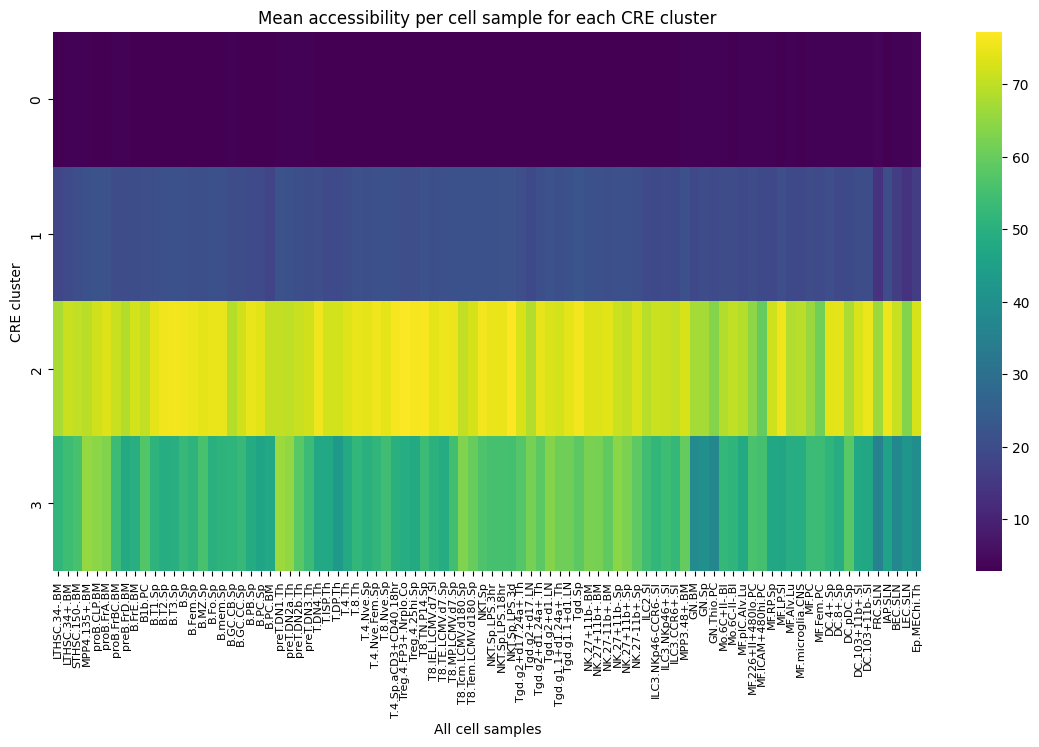

In [64]:
plt.figure(figsize=(14, 7))
sns.heatmap(
    cluster_all_mean, #Zeilen --> x-Achse, Spalten --> y-Achse, cluster spalte index nicht mitgenommen
    cmap="viridis",
    xticklabels=True
)

plt.title('Mean accessibility per cell sample for each CRE cluster')
plt.xlabel('All cell samples')
plt.ylabel('CRE cluster')

plt.xticks(rotation=90, fontsize=8)
plt.show()

The mean accessibility across all available cell types is visualized by the heatmap. It is confirmed that closed chromatin is captured by Cluster 0, mostly closed regions are represented by Cluster 1, and higher mean accessibility and variability are exhibited by Clusters 2 and 3.

However, due to the high cellular diversity, lineage-specific dynamics are visually lost. This is contrasted by the heatmap specifically for the γδ T-cell lineage, where clear shifts between cell types are visible.

## Clusters compared by signal strength: all cells vs linage-specific γδ T-cells

In [65]:
cre_parameter_all['cluster'].value_counts(normalize=True) #normalize=True: W-keit

cluster
0    0.920512
1    0.066133
2    0.010546
3    0.002810
Name: proportion, dtype: float64

In [66]:
cre_parameter['cluster'].value_counts(normalize=True) #normalize=True: W-keit

cluster
0    0.925521
3    0.061623
2    0.009916
1    0.002939
Name: proportion, dtype: float64

Both globally and within the cell lineages, 93% of the CREs are distributed across the clusters in the low-activity and low-variability clusters, and around 1% are in the high-activity and high-variability clusters.

## Conclusion

<div class="alert alert-block alert-info">
For CRE classification by signal strength and variability, elements were clustered based on their mean accessibility and variability across different cell types. CREs were separated by this in a very straightforward way, primarily by signal strength (low to high) and variability (constant to highly fluctuating). Thus, a distinction is mainly made by the clusters between “closed, low signal” and “open, high signal” regions, by which only a few patterns are captured (e.g., the sharp drop in accessibility specifically at the T.DN4.Th stage).

Moreover, because the vast majority of peaks are assigned to the inactive Cluster 0, detailed lineage-specific patterns fail to be captured by this approach. To identify γδ T-cell specific CREs, the hierarchical clustering from Section 1.3 is more effective, as peaks are directly grouped by their sample-specific correlation profiles.
</div>